In [1]:
import os
from copy import deepcopy
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

os.chdir(Path.cwd().parent)
print("new cwd:", Path.cwd())

new cwd: /home/oliver-hertach/Documents/Master/CO4/ClimbingVault


## Manual Segmentation
Using this dataset: 

https://www.kaggle.com/datasets/tomasslama/indoor-climbing-gym-hold-segmentation/data?select=sm

10 pictures were chosen for the project. To not overcomplicate things, mostly pictures where only one wall at the time is visible, with clearly visible and not too many holds were chosen. The pictures were from the "sm" folder from the dataset, and the original numbering was kept (e.g. 008.jpg). The pictures were manually segmented using Fiji. For each climbing hold color, a binary mask was created and stored as .png, with white pixels representing the holds and black pixels the background.  

Masks were manually created with reasonable visual precision, but not at single-pixel accuracy, as the focus of the project is comparative segmentation evaluation rather than precise annotation benchmarking.

## Shared constants

In [2]:
colors = {
    "red": [255, 0, 0],
    "blue": [0, 0, 255],
    "green": [0, 255, 0],
    "yellow": [255, 255, 0],
    "orange": [255, 165, 0],
    "purple": [128, 0, 128],
    "pink": [255, 105, 180],
    "black": [0, 0, 0],
    "downclimb": [128, 128, 128],
}

## Shared functions

In [3]:
def load_sample(img_id):
    img = cv.imread(f"data/images/{img_id}.jpg")

    mask_dir = f"data/masks/{img_id}"

    masks = {}

    for file in os.listdir(mask_dir):
        if file.endswith(".png"):
            color = file.replace(".png", "")
            masks[color] = cv.imread(os.path.join(mask_dir, file), 0)

    return img, masks


# Dice score


def dice_score(gt, pred):
    intersection = np.sum(gt * pred)
    return (2 * intersection) / (np.sum(gt) + np.sum(pred))

In [ ]:
def visualize(img, masks):
    masks_bin = {k: (v > 0).astype(np.uint8) for k, v in masks.items()}

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    overlay = img_rgb.copy()

    for name, mask in masks_bin.items():
        overlay[mask == 1] = colors[name]

    # side-by-side visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # original image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # overlay image
    axes[1].imshow(overlay)
    axes[1].set_title("Manual Segmentation Overlay")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    all_holds = np.zeros_like(next(iter(masks_bin.values())))

    for m in masks_bin.values():
        all_holds = np.logical_or(all_holds, m)

    all_holds = all_holds.astype(np.uint8)

    return all_holds

In [ ]:
for img_id in ["008", "042", "054", "079", "081", "083", "134", "137", "169", "254"]:
    img, masks = load_sample(img_id)
    visualize(img, masks)

## Combined plotting of RGB vs HSV vs YUV

RGB Dice: 0.08542657198437073
HSV Dice: 0.6550769464447221
YUV Dice: 0.4159076916544594


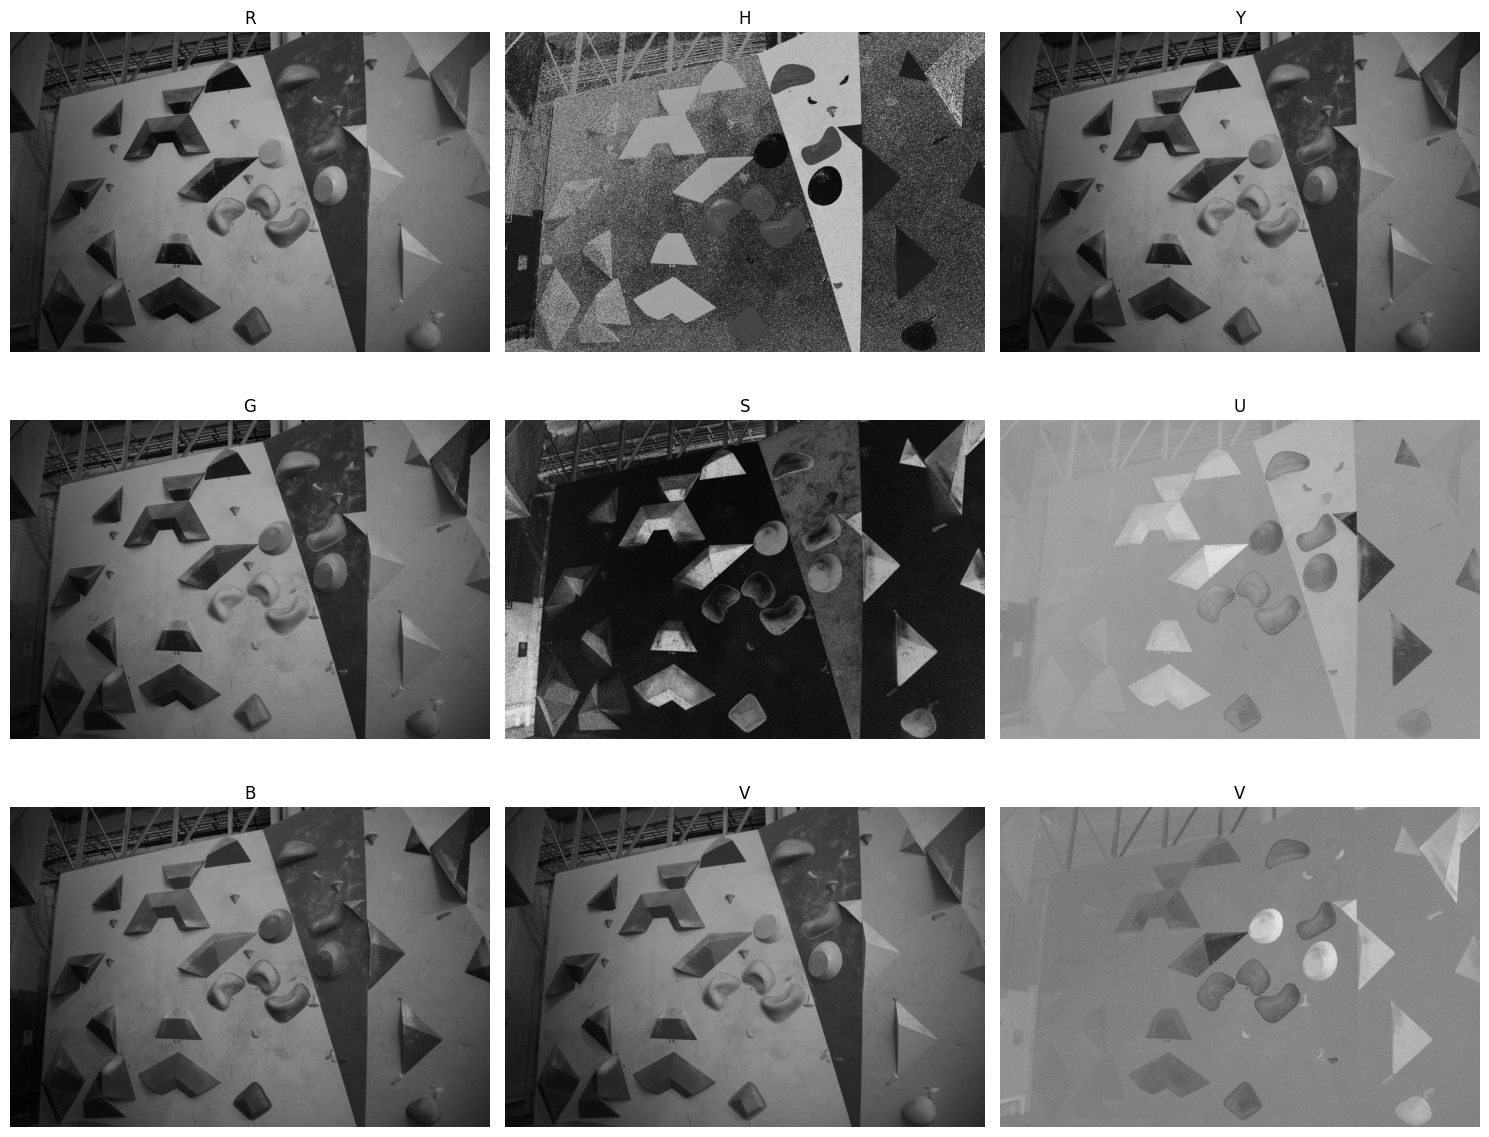

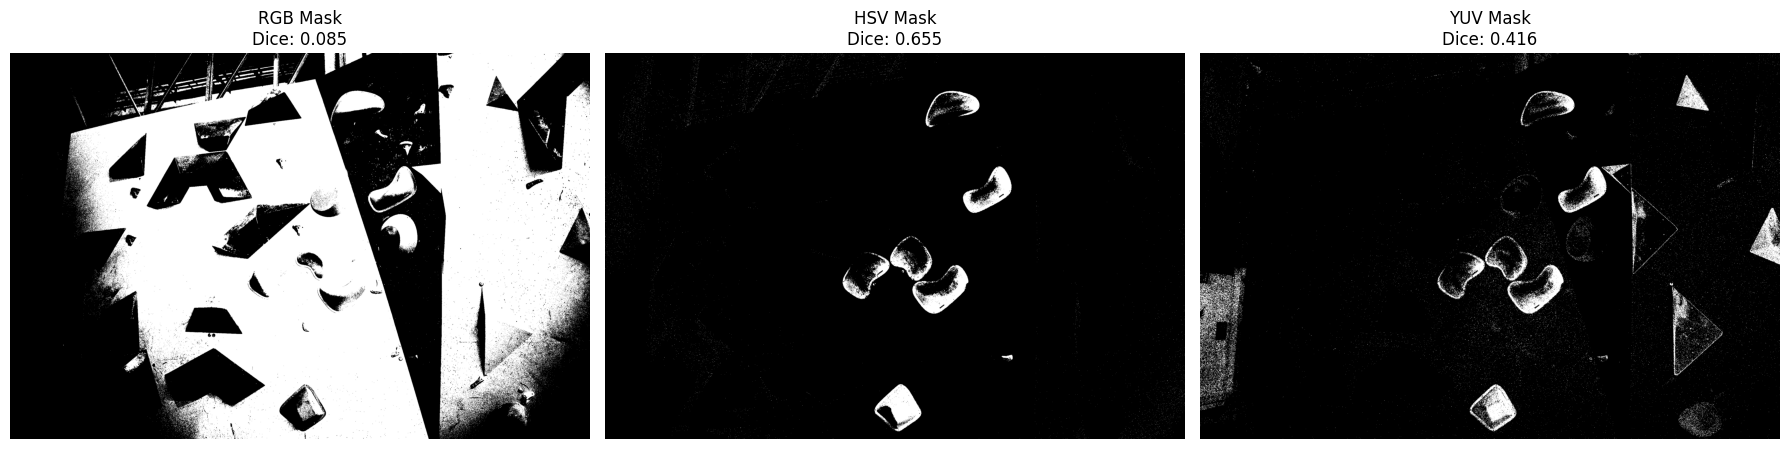

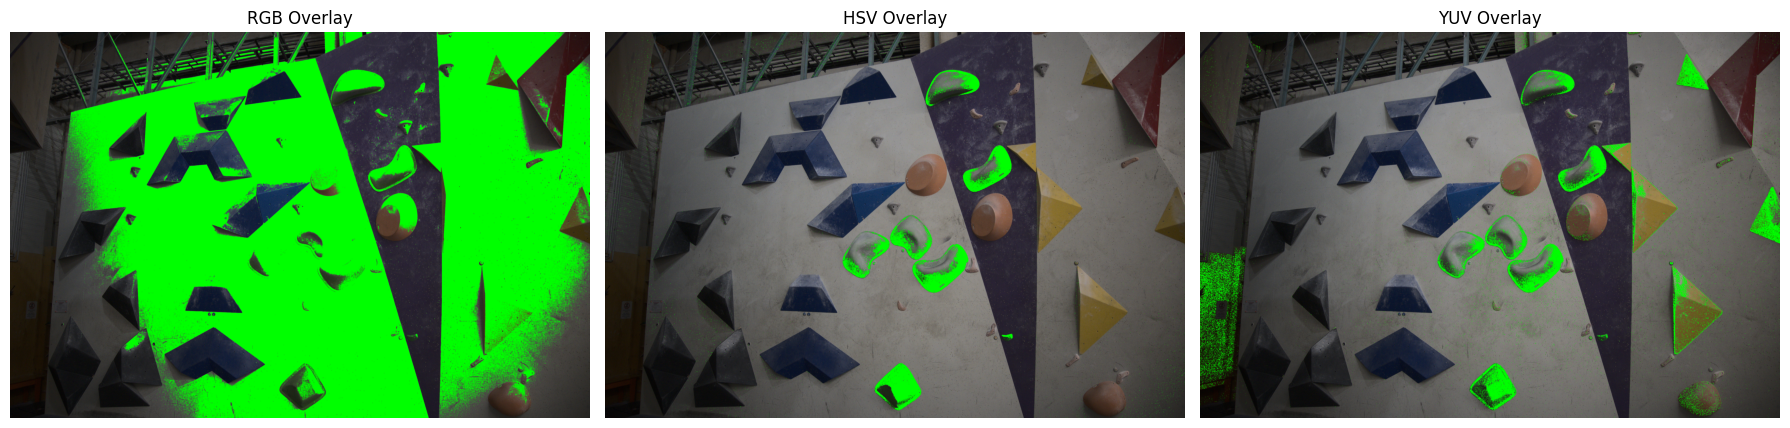

In [4]:
img_id = "008"

img, masks = load_sample(img_id)

# Convert color spaces
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
yuv = cv.cvtColor(img, cv.COLOR_BGR2YUV)

# Ground truth
gt = (masks["green"] > 0).astype(np.uint8)

# -----------------------------
# RGB segmentation
# -----------------------------
rgb_lower = np.array([0, 80, 0])
rgb_upper = np.array([180, 255, 180])

rgb_mask = cv.inRange(img_rgb, rgb_lower, rgb_upper)
rgb_pred = (rgb_mask > 0).astype(np.uint8)

# -----------------------------
# HSV segmentation
# -----------------------------
hsv_lower = np.array([35, 50, 50])
hsv_upper = np.array([85, 255, 255])

hsv_mask = cv.inRange(hsv, hsv_lower, hsv_upper)
hsv_pred = (hsv_mask > 0).astype(np.uint8)

# -----------------------------
# YUV segmentation
# -----------------------------
yuv_lower = np.array([0, 40, 0])
yuv_upper = np.array([255, 120, 140])

yuv_mask = cv.inRange(yuv, yuv_lower, yuv_upper)
yuv_pred = (yuv_mask > 0).astype(np.uint8)

# -----------------------------
# Dice scores
# -----------------------------
rgb_dice = dice_score(gt, rgb_pred)
hsv_dice = dice_score(gt, hsv_pred)
yuv_dice = dice_score(gt, yuv_pred)

print("RGB Dice:", rgb_dice)
print("HSV Dice:", hsv_dice)
print("YUV Dice:", yuv_dice)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# -------------------
# RGB
# -------------------

# title
axes[0, 0].set_ylabel("RGB", rotation=0, labelpad=40)
axes[0, 1].set_ylabel("HSV", rotation=0, labelpad=40)
axes[0, 2].set_ylabel("YUV", rotation=0, labelpad=40)

axes[0, 0].imshow(img_rgb[:, :, 0], cmap="gray")
axes[0, 0].set_title("R")
axes[0, 0].axis("off")

axes[1, 0].imshow(img_rgb[:, :, 1], cmap="gray")
axes[1, 0].set_title("G")
axes[1, 0].axis("off")

axes[2, 0].imshow(img_rgb[:, :, 2], cmap="gray")
axes[2, 0].set_title("B")
axes[2, 0].axis("off")

# -------------------
# HSV
# -------------------
axes[0, 1].imshow(hsv[:, :, 0], cmap="gray")
axes[0, 1].set_title("H")
axes[0, 1].axis("off")

axes[1, 1].imshow(hsv[:, :, 1], cmap="gray")
axes[1, 1].set_title("S")
axes[1, 1].axis("off")

axes[2, 1].imshow(hsv[:, :, 2], cmap="gray")
axes[2, 1].set_title("V")
axes[2, 1].axis("off")

# -------------------
# YUV
# -------------------
axes[0, 2].imshow(yuv[:, :, 0], cmap="gray")
axes[0, 2].set_title("Y")
axes[0, 2].axis("off")

axes[1, 2].imshow(yuv[:, :, 1], cmap="gray")
axes[1, 2].set_title("U")
axes[1, 2].axis("off")

axes[2, 2].imshow(yuv[:, :, 2], cmap="gray")
axes[2, 2].set_title("V")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# MASK VISUALIZATION
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_mask, cmap="gray")
axes[0].set_title(f"RGB Mask\nDice: {rgb_dice:.3f}")
axes[0].axis("off")

axes[1].imshow(hsv_mask, cmap="gray")
axes[1].set_title(f"HSV Mask\nDice: {hsv_dice:.3f}")
axes[1].axis("off")

axes[2].imshow(yuv_mask, cmap="gray")
axes[2].set_title(f"YUV Mask\nDice: {yuv_dice:.3f}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# -----------------------------
# OVERLAY VISUALIZATION
# -----------------------------
rgb_overlay = img_rgb.copy()
rgb_overlay[rgb_pred == 1] = [0, 255, 0]

hsv_overlay = img_rgb.copy()
hsv_overlay[hsv_pred == 1] = [0, 255, 0]

yuv_overlay = img_rgb.copy()
yuv_overlay[yuv_pred == 1] = [0, 255, 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(rgb_overlay)
axes[0].set_title("RGB Overlay")
axes[0].axis("off")

axes[1].imshow(hsv_overlay)
axes[1].set_title("HSV Overlay")
axes[1].axis("off")

axes[2].imshow(yuv_overlay)
axes[2].set_title("YUV Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Baseline loop

### Configuration

In [5]:
img_dir = Path("data/images")

colors_list = list(colors.keys())
image_ids = sorted([f.stem for f in img_dir.glob("*.jpg")])
print(image_ids)

['008', '042', '054', '079', '081', '083', '134', '137', '169', '254']


### Thresholds

In [6]:
thresholds = {
    "HSV": {
        "red": {"lower": [0, 80, 80], "upper": [180, 255, 255]},
        "green": {"lower": [35, 50, 50], "upper": [85, 255, 255]},
        "blue": {"lower": [90, 50, 50], "upper": [130, 255, 255]},
        "yellow": {"lower": [20, 80, 80], "upper": [35, 255, 255]},
        "orange": {"lower": [10, 80, 80], "upper": [20, 255, 255]},
        "purple": {"lower": [140, 50, 50], "upper": [160, 255, 255]},
        "pink": {"lower": [160, 50, 50], "upper": [180, 255, 255]},
        "black": {"lower": [60, 0, 0], "upper": [120, 255, 60]},
        "downclimb": {"lower": [0, 0, 60], "upper": [180, 50, 200]},
    },
    "RGB": {
        "red": {"lower": [150, 0, 0], "upper": [255, 100, 100]},
        "green": {"lower": [0, 150, 0], "upper": [100, 255, 100]},
        "blue": {"lower": [0, 0, 150], "upper": [100, 100, 255]},
        "yellow": {"lower": [150, 150, 0], "upper": [255, 255, 120]},
        "orange": {"lower": [150, 80, 0], "upper": [255, 180, 100]},
        "purple": {"lower": [120, 0, 120], "upper": [200, 100, 255]},
        "pink": {"lower": [180, 100, 150], "upper": [255, 180, 220]},
        "black": {"lower": [0, 0, 0], "upper": [60, 60, 60]},
        "downclimb": {"lower": [120, 120, 120], "upper": [200, 200, 200]},
    },
    "YUV": {
        "red": {"lower": [0, 0, 150], "upper": [255, 120, 255]},
        "green": {"lower": [0, 0, 0], "upper": [255, 120, 140]},
        "blue": {"lower": [0, 140, 0], "upper": [255, 255, 255]},
        "yellow": {"lower": [150, 0, 0], "upper": [255, 120, 120]},
        "orange": {"lower": [120, 0, 100], "upper": [255, 140, 200]},
        "purple": {"lower": [100, 80, 120], "upper": [200, 150, 255]},
        "pink": {"lower": [120, 80, 150], "upper": [255, 160, 255]},
        "black": {"lower": [0, 0, 0], "upper": [80, 80, 80]},
        "downclimb": {"lower": [60, 60, 60], "upper": [180, 180, 180]},
    },
}

### Segmenation functions

In [7]:
def segment_color(img, color, method, thresholds):
    method = method.upper()

    if method == "HSV":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    elif method == "RGB":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    elif method == "YUV":
        img_cvt = cv.cvtColor(img, cv.COLOR_BGR2YUV)
    else:
        raise ValueError(method)

    lower = np.array(thresholds[method][color]["lower"], dtype=np.uint8)
    upper = np.array(thresholds[method][color]["upper"], dtype=np.uint8)

    mask = cv.inRange(img_cvt, lower, upper)
    return (mask > 0).astype(np.uint8)

### Additional Pipeline

In [8]:
# image
def blur(img):
    return cv.GaussianBlur(img, (5, 5), 0)


def equalize_hsv(img):
    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
    hsv[:, :, 2] = cv.equalizeHist(hsv[:, :, 2])
    return cv.cvtColor(hsv, cv.COLOR_HSV2BGR)


def denoise(img):
    return cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)


def apply_pipeline(img, pipeline):
    for stage, func in pipeline:
        if stage == "image":
            img = func(img)
    return img

In [9]:
# Mask --------------
def open_mask(mask):
    kernel = np.ones((5, 5), np.uint8)

    return cv.morphologyEx(mask.astype(np.uint8), cv.MORPH_OPEN, kernel)


def close_mask(mask):
    kernel = np.ones((3, 3), np.uint8)

    return cv.morphologyEx(mask.astype(np.uint8), cv.MORPH_CLOSE, kernel)


def connected_components_filter(mask, min_area=500):

    mask = mask.astype(np.uint8)

    if len(mask.shape) == 3:
        mask = cv.cvtColor(mask, cv.COLOR_BGR2GRAY)

    num_labels, labels, stats, _ = cv.connectedComponentsWithStats(mask, connectivity=8)

    cleaned = np.zeros_like(mask)

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == i] = 1

    return cleaned.astype(np.uint8)

In [10]:
def apply_mask_pipeline(mask, pipeline):
    for stage, step in pipeline:
        if stage == "mask":
            mask = step(mask)

    return mask

### Experiment runner

In [11]:
def run_experiment(image_ids, methods, colors, thresholds, pipeline=None):

    results = []

    for img_id in image_ids:
        img, masks = load_sample(img_id)

        # -------------------------
        # IMAGE PIPELINE (ONCE)
        # -------------------------
        img_proc = img.copy()

        if pipeline:
            for stage, func in pipeline:
                if stage == "image":
                    img_proc = func(img_proc)

        # -------------------------
        # LOOP COLORS / METHODS
        # -------------------------
        for color in colors:
            if color not in masks:
                continue

            gt = (masks[color] > 0).astype(np.uint8)

            for method in methods:
                pred = segment_color(img_proc, color, method, thresholds)

                # -------------------------
                # MASK PIPELINE
                # -------------------------
                if pipeline:
                    for stage, func in pipeline:
                        if stage == "mask":
                            pred = func(pred)

                score = dice_score(gt, pred)

                results.append(
                    {"image": img_id, "color": color, "method": method, "dice": score}
                )

    return pd.DataFrame(results)

## Running and Evaluating of Baseline

In [12]:
def compute_heatmap(df, methods):
    return df.pivot_table(
        index="color", columns="method", values="dice", aggfunc="mean"
    ).reindex(columns=methods)


def evaluate(df, methods, title="Evaluation"):

    pivot = compute_heatmap(df, methods)

    # -------------------------
    # GLOBAL METHOD SCORES
    # -------------------------
    method_means = df.groupby("method")["dice"].mean().reindex(methods)

    print(f"\n{title}")
    print("-" * len(title))
    for m, score in method_means.items():
        print(f"{m:10s}: {score:.4f}")

    # -------------------------
    # HEATMAP
    # -------------------------
    plt.figure(figsize=(8, 5))

    im = plt.imshow(pivot, aspect="auto", vmin=0, vmax=1)

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    # annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            if pd.notna(value):
                plt.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="white" if value < 0.5 else "black",
                )

    plt.colorbar(im, label="Dice score")
    plt.title(title)

    plt.tight_layout()
    plt.show()

### Running and showing experiments


Baseline
--------
RGB       : 0.0207
YUV       : 0.1313
HSV       : 0.2686


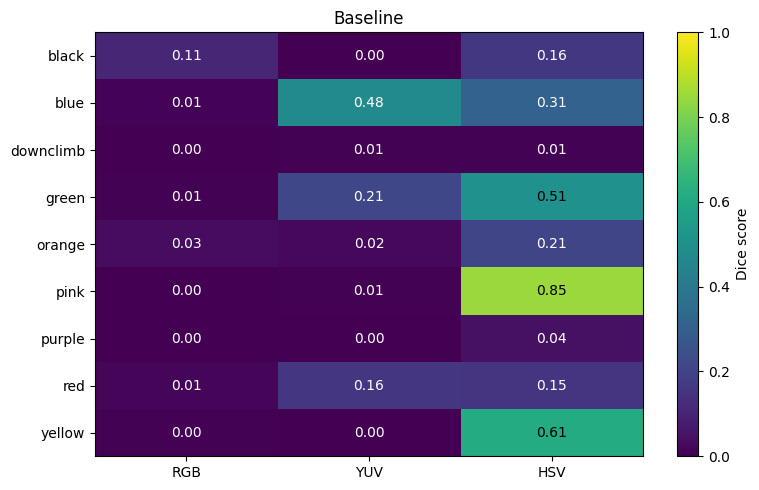

Base run complete
Blur run complete
Close mask run complete
Open mask run complete
Connected components mask run complete
Denoise run complete


In [13]:
methods = ["RGB", "YUV", "HSV"]

# base
df_base = run_experiment(image_ids, methods, colors_list, thresholds)


evaluate(df_base, methods, "Baseline")

print("Base run complete")

# blur
df_blur = run_experiment(
    image_ids, methods, colors_list, thresholds, pipeline=[("image", blur)]
)
print("Blur run complete")

# close_mask
df_close = run_experiment(
    image_ids, methods, colors_list, thresholds, pipeline=[("mask", close_mask)]
)
print("Close mask run complete")

# open_mask
df_open = run_experiment(
    image_ids, methods, colors_list, thresholds, pipeline=[("mask", open_mask)]
)
print("Open mask run complete")


df_cc = run_experiment(
    image_ids,
    methods,
    colors_list,
    thresholds,
    pipeline=[("mask", connected_components_filter)],
)
print("Connected components mask run complete")

# denoise
df_denoise = run_experiment(
    image_ids, methods, colors_list, thresholds, pipeline=[("image", denoise)]
)
print("Denoise run complete")

In [14]:
def summarize(df, methods):
    return df.groupby("method")["dice"].mean().reindex(methods)


def build_comparison_table(pipelines, methods):
    data = {}

    for name, config in pipelines.items():
        df = config["df"]

        data[name] = df.groupby("method")["dice"].mean().reindex(methods)

    return pd.DataFrame(data)

In [15]:
def plot_pipeline_comparison(table, pipelines):

    x = np.arange(len(table.index))
    width = 0.8 / len(table.columns)

    plt.figure(figsize=(10, 5))

    baseline_col = table.columns[0]
    baseline = table[baseline_col]

    # bars
    for i, col in enumerate(table.columns):
        values = table[col].values
        color = pipelines[col]["color"]

        for j, value in enumerate(values):
            worse_than_baseline = value < baseline.iloc[j]

            plt.bar(
                x[j] + i * width,
                value,
                width,
                color=color,
                hatch="//" if worse_than_baseline else None,
                alpha=0.9,
            )

    # clean custom legend
    legend_handles = [
        Patch(facecolor=config["color"], label=name)
        for name, config in pipelines.items()
    ]

    plt.legend(handles=legend_handles)

    plt.xticks(x + width * (len(table.columns) - 1) / 2, table.index)

    plt.ylabel("Mean Dice Score")
    plt.title("Pipeline Comparison")
    plt.ylim(0, 1)

    plt.show()

In [16]:
pipelines = {
    "baseline": {
        "df": df_base,
        "color": "steelblue",
    },
    "blur": {
        "df": df_blur,
        "color": "orange",
    },
    "denoise": {
        "df": df_denoise,
        "color": "green",
    },
    "open": {
        "df": df_open,
        "color": "purple",
    },
    "close_mask": {
        "df": df_close,
        "color": "red",
    },
    "connected_components": {
        "df": df_cc,
        "color": "brown",
    },
}

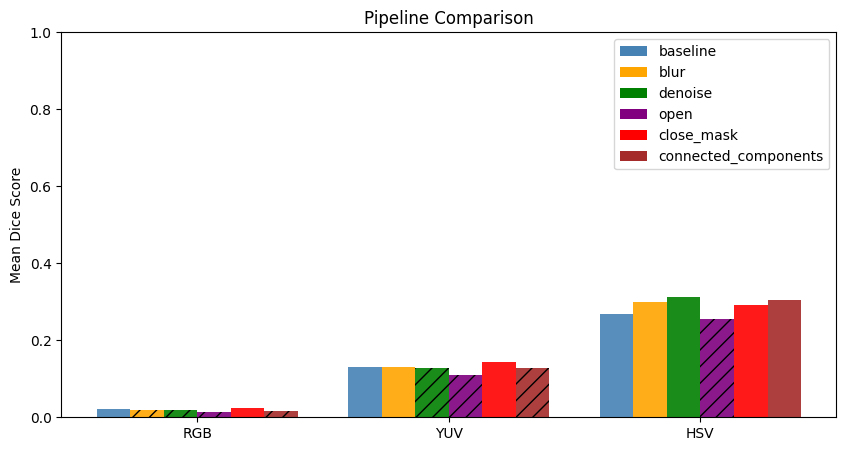

In [17]:
table = build_comparison_table(pipelines, methods)
plot_pipeline_comparison(table, pipelines)

## HSV specific optimizing

In [18]:
def clahe_hsv(img, clip_limit=2.0, tile_grid_size=(8, 8)):

    hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

    h, s, v = cv.split(hsv)

    clahe = cv.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    v_clahe = clahe.apply(v)

    hsv_clahe = cv.merge([h, s, v_clahe])

    return cv.cvtColor(hsv_clahe, cv.COLOR_HSV2BGR)

In [19]:
base_hsv_pipeline = [
    ("image", blur),
    ("image", denoise),
    # ("mask", open_mask), # excluded as this seems to lower the dice score
    ("mask", close_mask),
    ("mask", connected_components_filter),
]

In [20]:
pipeline_eq = base_hsv_pipeline + [("image", equalize_hsv)]
pipeline_clahe = base_hsv_pipeline + [("image", clahe_hsv)]
pipeline_both = base_hsv_pipeline + [("image", equalize_hsv)] + [("image", clahe_hsv)]

df_hsv_base = run_experiment(image_ids, ["HSV"], colors_list, thresholds, pipeline=[])

df_hsv_full = run_experiment(
    image_ids, ["HSV"], colors_list, thresholds, pipeline=base_hsv_pipeline
)

df_hsv_eq = run_experiment(
    image_ids, ["HSV"], colors_list, thresholds, pipeline=pipeline_eq
)

df_hsv_clahe = run_experiment(
    image_ids, ["HSV"], colors_list, thresholds, pipeline=pipeline_clahe
)

df_hsv_both = run_experiment(
    image_ids, ["HSV"], colors_list, thresholds, pipeline=pipeline_both
)

In [21]:
pipelines_hsv = {
    "baseline HSV": {"df": df_hsv_base, "color": "steelblue"},
    "full pipeline": {"df": df_hsv_full, "color": "orange"},
    "+ equalize": {"df": df_hsv_eq, "color": "green"},
    "+ CLAHE": {"df": df_hsv_clahe, "color": "purple"},
    "+ both": {"df": df_hsv_both, "color": "red"},
}

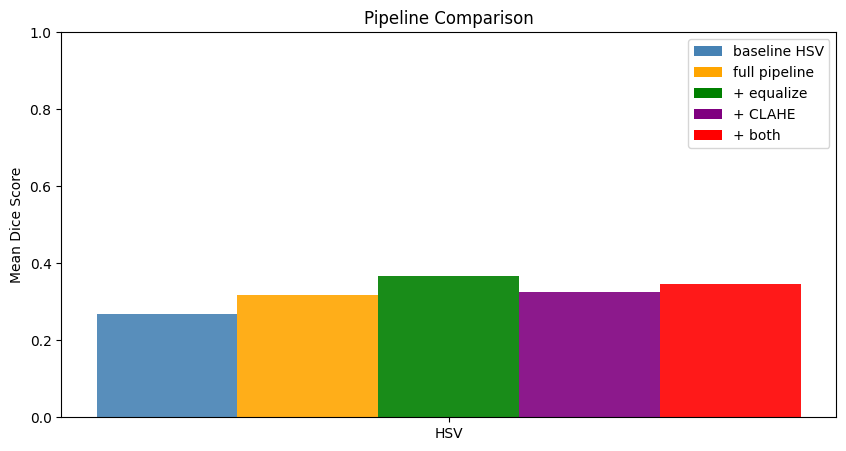

In [22]:
table_hsv = build_comparison_table(pipelines_hsv, ["HSV"])
plot_pipeline_comparison(table_hsv, pipelines_hsv)

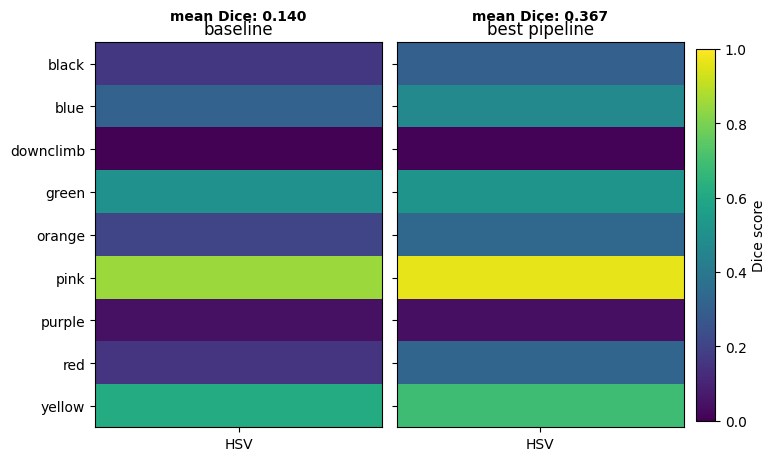

In [23]:
def compare_heatmaps(experiments, methods):

    n = len(experiments)

    fig, axes = plt.subplots(1, n, figsize=(3 * n + 2, 5), sharey=True)

    if n == 1:
        axes = [axes]

    last_im = None

    for i, (ax, (name, df)) in enumerate(zip(axes, experiments.items())):
        pivot = compute_heatmap(df, methods)

        mean_dice = df["dice"].mean()

        im = ax.imshow(pivot, aspect="auto", vmin=0, vmax=1)

        last_im = im

        # x labels
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)

        # y labels only once
        ax.set_yticks(range(len(pivot.index)))

        if i == 0:
            ax.set_yticklabels(pivot.index)
        else:
            ax.tick_params(labelleft=False)

        ax.set_title(name)

        ax.text(
            0.5,
            1.05,
            f"mean Dice: {mean_dice:.3f}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    # MUCH tighter spacing
    fig.subplots_adjust(wspace=0.05)

    # dedicated colorbar axis on the far right
    cbar = fig.colorbar(last_im, ax=axes, fraction=0.03, pad=0.02)

    cbar.set_label("Dice score")

    plt.show()


compare_heatmaps({"baseline": df_base, "best pipeline": df_hsv_eq}, ["HSV"])

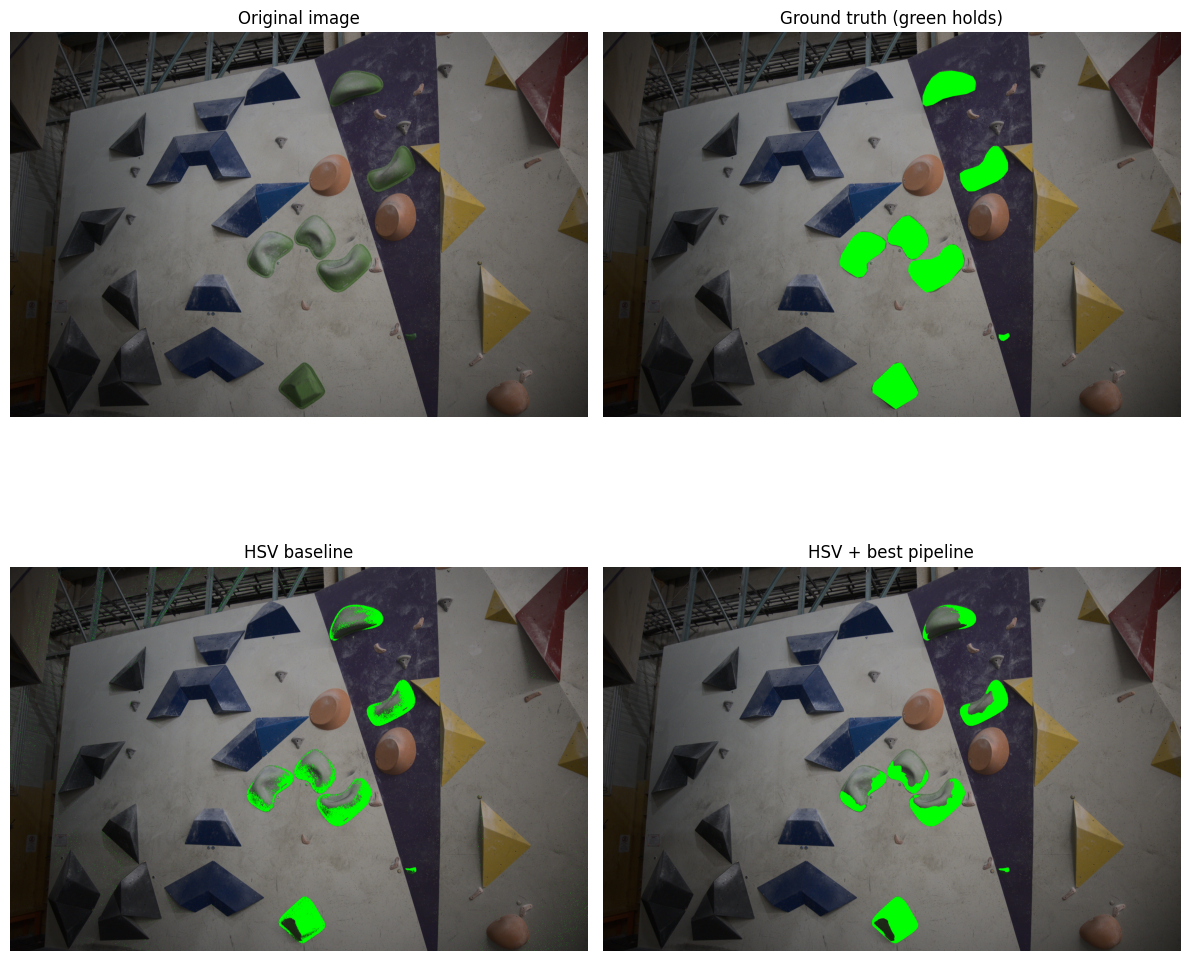

In [24]:
def make_overlay(img_rgb, mask, color=(0, 255, 0)):
    overlay = img_rgb.copy()
    overlay[mask == 1] = color
    return overlay


img, masks = load_sample(img_id)
gt = (masks["green"] > 0).astype(np.uint8)

# -------------------------
# PIPELINES
# -------------------------
img_base = apply_pipeline(img, [])
pred_base = segment_color(img_base, "green", "HSV", thresholds)

img_full = apply_pipeline(img, pipeline_eq)
pred_full = segment_color(img_full, "green", "HSV", thresholds)
pred_full = apply_mask_pipeline(pred_full, pipeline_eq)

# -------------------------
# VISUAL BASE IMAGE
# -------------------------
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

overlay_gt = make_overlay(img_rgb, gt, color=(0, 255, 0))
overlay_base = make_overlay(img_rgb, pred_base, color=(0, 255, 0))
overlay_full = make_overlay(img_rgb, pred_full, color=(0, 255, 0))

# -------------------------
# PLOT 2x2
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 1.1 original image
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

# 1.2 ground truth
axes[0, 1].imshow(overlay_gt)
axes[0, 1].set_title("Ground truth (green holds)")
axes[0, 1].axis("off")

# 2.1 baseline
axes[1, 0].imshow(overlay_base)
axes[1, 0].set_title("HSV baseline")
axes[1, 0].axis("off")

# 2.2 best pipeline
axes[1, 1].imshow(overlay_full)
axes[1, 1].set_title("HSV + best pipeline")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

In [25]:
def tune_hsv_color(
    image_ids, color, thresholds, pipeline, lower_h_range, upper_h_range
):

    best_score = -1
    best_threshold = None

    for lower_h in lower_h_range:
        for upper_h in upper_h_range:
            if lower_h >= upper_h:
                continue

            # copy thresholds safely
            trial = deepcopy(thresholds)

            # modify ONLY this color
            trial["HSV"][color]["lower"][0] = lower_h
            trial["HSV"][color]["upper"][0] = upper_h

            # run experiment ONLY for HSV + one color
            df = run_experiment(
                image_ids=image_ids,
                methods=["HSV"],
                colors=[color],
                thresholds=trial,
                pipeline=pipeline,
            )

            score = df["dice"].mean()

            if score > best_score:
                best_score = score
                best_threshold = {
                    "lower": trial["HSV"][color]["lower"].copy(),
                    "upper": trial["HSV"][color]["upper"].copy(),
                }

    return best_threshold, best_score

In [26]:
# best_threshold, best_score = tune_hsv_color(
#     image_ids=image_ids,
#     color="red",
#     thresholds=thresholds,
#     pipeline=pipeline_eq,
#     lower_h_range=range(0, 31, 5),
#     upper_h_range=range(150, 181, 5)
# )

# print("red")
# print(best_threshold)
# print(best_score)